# Example: Choosing the Optimal Point on the Capital Allocation Line

In L7a, investors with our inputs held the same tangent portfolio and differed only in the risk-free fraction $w_{f}$. Which fraction maximizes a risk-averse investor's utility, and what risk aversion does a client's interview answer imply?

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Rebuild the capital allocation line:__ The capital allocation line runs from the risk-free asset through the tangent portfolio. We'll find the tangent portfolio with single index model inputs and compute its expected growth rate and risk.
> * __Choose the optimal complete portfolio:__ Mean-variance utility trades expected growth against risk through a risk-aversion coefficient. We'll compute the optimal risk-free fraction for several coefficients and see where each investor's indifference curve touches the line.
> * __Infer a client's risk aversion:__ An interview answer fixes a risk-free fraction, and the optimal-fraction formula can be run backward. We'll compute the risk aversion each answer implies and compare the client's choice with the one the 2025 data would have made.

In this example, we use SIM parameters estimated from 2014 to 2024 data to find the tangent portfolio and the optimal risk-free fraction. We then compare the client's choice with what the tangent portfolio delivered in 2025.

Let's get started!

___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the packages used here.

Let's set up our code environment:

In [1]:
# Load the course environment, market data, and portfolio solver -
include(joinpath(@__DIR__, "Include.jl")); # resolve setup relative to this notebook

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

### Data
The SIM parameters come from daily volume-weighted average prices (VWAP) of [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) firms from 2014 to 2024. We use the 2025 prices only in Task 3.

Let's load the 2025 testing data with [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet), keep the tickers with as many price records as `AAPL`, and store them in `dataset_2025::Dict{String,DataFrame}`:

In [2]:
dataset_2025 = let # variables created inside a let block stay local to it

    # Load the testing prices, calendar year 2025 -
    original_dataset = MyTestingMarketDataSet() |> x-> x["dataset"]; # default year is 2025
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL's 2025 trading days
    dataset = Dict{String, DataFrame}(); # complete 2025 histories, keyed by ticker

    # Keep only the tickers with as many price rows as AAPL -
    for (ticker, data) ∈ original_dataset # each entry unpacks into (key, value), in no fixed order
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # a let block returns its last expression, which becomes the global dataset_2025
end;

We also load the SIM parameters saved by the L6b estimation example, using [the `JLD2.load(...)` function](https://juliaio.github.io/JLD2.jl/stable/basic_usage/#FileIO-interface). For each firm, the archive holds $\hat{\alpha}_{i}$, $\hat{\beta}_{i}$, and the residual variance $s^{2}_{g,\varepsilon,i}$. It also holds the market's training mean $g^{\prime}_{M}$ and variance $s^{2}_{g,M}$.

After checking the archive's conventions, we store these in `sim_parameters::Dict{String,NamedTuple}`, `g_market_mean::Float64`, and `σ²_market::Float64`:

In [3]:
sim_parameters, g_market_mean, σ²_market = let

    # Load the archive, a Dict of saved objects -
    archive = JLD2.load(joinpath(_PATH_TO_DATA, "SIMs-SP500-01-03-14-to-12-31-24.jld2"));

    # checks: the archive's conventions -
    @assert archive["schema_version"] == 2 # the archive layout this notebook reads
    @assert archive["market_ticker"] == "SPY" # the market growth rate is SPY's
    @assert isapprox(archive["delta_t"], 1/252) # growth rates used a one-day time step
    @assert archive["variance_convention"] == "growth_rate" # residual variances in (1/yr)²

    # ticker => (alpha, beta, training_variance, ...), then g′_M (1/yr) and s²_{g,M} (1/yr²) -
    (archive["data"], archive["market_mean"], archive["market_variance"]);
end;

### Constants
Finally, we set the time step, the risk-free growth rate, the sweep settings, and the four answers to the L6b interview's risk question. If `data/my-client.toml` has been copied from L6b, we read the client's risk-free fraction. Otherwise, the client keeps a quarter in T-bills. If the L7b income-gamble interview has written `data/my-risk-aversion.toml`, we also read the client's range of $A$. The comments below give the meaning and units.

In [4]:
# Set the time unit, the risk-free rate, and the sweep settings -
Δt = (1.0/252.0); # time step (1 trading day, in years)
g_f = 0.041; # risk-free growth rate (1/yr), from a 4.16% one-year Treasury yield, end of 2024
number_of_points = 101; # number of growth targets in the tangent-portfolio sweep
risk_aversion_values = [2.0, 4.0, 6.0, 8.0, 10.0, 20.0]; # risk-aversion coefficients A for Task 2 (dimensionless)
plotted_risk_aversion = [4.0, 6.0, 10.0]; # the A values whose indifference curves Task 2 draws

# List the interview's answers and their risk-free fractions -
interview_answers = ["Keep half in T-bills", "Keep a quarter in T-bills", "Fully invested", "Borrow a quarter more"];
interview_fractions = [0.50, 0.25, 0.0, -0.25]; # w_f for each answer (negative = borrowing)

# Read the client's risk-free fraction, if the interview has written one -
client_w_f = 0.25; # default client: keep a quarter in T-bills
path_to_client_settings = joinpath(_PATH_TO_DATA, "my-client.toml"); # copied from the L6b client interview
if (isfile(path_to_client_settings))
    client_w_f = TOML.parsefile(path_to_client_settings)["client"]["risk_free_fraction"]; # w_f from the interview
end
println("client w_f = $(client_w_f)")

# Read the client's range of A, if the income-gamble interview has written one -
client_A_range = nothing; # (low, high) bounds on A, or nothing without the interview
path_to_gamble = joinpath(_PATH_TO_DATA, "my-risk-aversion.toml"); # written by interview/income-gamble.jl
if (isfile(path_to_gamble))
    gamble = TOML.parsefile(path_to_gamble)["income_gamble"]; # the interview's results table
    client_A_range = (gamble["risk_aversion_low"], gamble["risk_aversion_high"]); # bounds on A (dimensionless)
    println("income-gamble range: $(round(client_A_range[1], digits=2)) < A < $(round(client_A_range[2], digits=2))")
end

# checks -
@assert client_w_f < 1 # a client fully in T-bills holds no risk, so no A makes that choice optimal

client w_f = 0.0


___

## Task 1: Find the Tangent Portfolio and Its Capital Allocation Line
In this task, we find the tangent portfolio with SIM inputs and compute the expected growth rate and risk that set its capital allocation line.

### Choose the firms
We start from the thirteen firms used in L6a and L7a. If the L6b client interview files have been copied into this notebook's `data` folder, we use the list in `data/my-tickers.csv` instead. Specify the ticker symbols in `my_list_of_tickers::Array{String,1}`:

In [5]:
# Fix the asset universe before looking at 2025 performance -
# This order sets the order of every mean, covariance row and column, weight, and price column.
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"]; # the 13 L6a firms

# Use the client interview's list instead, if the interview has written one -
path_to_client_tickers = joinpath(_PATH_TO_DATA, "my-tickers.csv"); # copied from the L6b client interview
if (isfile(path_to_client_tickers))
    my_list_of_tickers = String.(CSV.read(path_to_client_tickers, DataFrame).ticker); # String.(...) converts CSV's compact strings
end
println("M = $(length(my_list_of_tickers)) firms: $(join(my_list_of_tickers, ", "))")

M = 30 firms: GOOG, DIS, NWS, HD, NKE, LOW, SYY, EL, ADM, BRK.B, V, L, SYK, A, MTD, AME, HON, ITW, APH, ACN, MSFT, ECL, PPG, AVY, PLD, BXP, ARE, AES, CNP, NRG


### Build the inputs
As in the L7a lecture, the SIM inputs are given by:

$$
\hat{\mathbf{g}}_{\text{SIM}} = \hat{\boldsymbol{\alpha}} + \hat{\boldsymbol{\beta}}\,g^{\prime}_{M},
\qquad
\hat{\mathbf{\Sigma}}_{g,\text{SIM}} = s^{2}_{g,M}\,\hat{\boldsymbol{\beta}}\hat{\boldsymbol{\beta}}^{\top} + \hat{\mathbf{D}}_{g}
$$

where the diagonal matrix $\hat{\mathbf{D}}_{g}$ holds the residual variances.

We store the inputs in `ĝ_sim::Array{Float64,1}` and `Σ̂_g_sim::Array{Float64,2}`:

In [6]:
ĝ_sim, Σ̂_g_sim = let

    # Build the SIM inputs from the archive, in ticker order -
    α̂ = [sim_parameters[ticker].alpha for ticker ∈ my_list_of_tickers]; # intercepts (1/yr)
    β̂ = [sim_parameters[ticker].beta for ticker ∈ my_list_of_tickers]; # betas (dimensionless)
    s²_ε = [sim_parameters[ticker].training_variance for ticker ∈ my_list_of_tickers]; # residual variances (1/yr²)
    ĝ_sim = α̂ .+ β̂ .* g_market_mean; # SIM mean vector α̂ + β̂ g′_M (1/yr)
    # β̂ * β̂' is the M × M outer product. |> Matrix turns the sum into an ordinary dense matrix.
    Σ̂_g_sim = σ²_market .* (β̂ * β̂') .+ Diagonal(s²_ε) |> Matrix; # s²_{g,M} β̂β̂ᵀ + D̂_g (1/yr²)

    # checks: every firm is in the archive, the firms share the same 2025 dates (Task 3 pairs
    # 2025 prices by row position), and the inputs are usable. @assert stops the cell if a check is false.
    for ticker ∈ my_list_of_tickers
        @assert haskey(sim_parameters, ticker) "$(ticker) has no SIM parameters in the archive"
        @assert dataset_2025[ticker].timestamp == dataset_2025["AAPL"].timestamp
    end
    @assert isposdef(Σ̂_g_sim) # the covariance must be positive definite
    @assert maximum(ĝ_sim) > g_f "choose at least one firm whose mean growth rate exceeds g_f"

    (ĝ_sim, Σ̂_g_sim); # this tuple unpacks, in order, into the two names on the first line
end;

### Find the tangent portfolio
As in the L7a example, we solve the risky and risk-free problem (SIM-2) for a sweep of growth targets. Then we divide each solution by its risky fraction. By SIM-3, every rescaled solution is the tangent portfolio $\mathbf{w}_{\mathcal{T}}$ until a bound $w_{i}\leq1$ binds.

Let's build the problem as an instance of [the `MyMarkowitzRiskyRiskFreePortfolioChoiceProblem` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.MyMarkowitzRiskyRiskFreePortfolioChoiceProblem) using [the `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.build-Tuple{Type{MyMarkowitzRiskyRiskFreePortfolioChoiceProblem},%20NamedTuple}), and store it in `problem_sim`:

In [7]:
problem_sim = let
    M = length(my_list_of_tickers); # number of firms

    # Set the long-only bounds 0 ≤ wᵢ ≤ 1 on the risky weights -
    # The risk-free fraction w_f = 1 - 1ᵀw has no bound, so the solver may borrow.
    bounds = zeros(M, 2); # one row per firm, column 1 holds the lower bounds (zero)
    bounds[:,2] .= 1.0; # .= fills column 2, the upper bounds, with ones in place

    # Build the problem, passing its fields as a named tuple -
    build(MyMarkowitzRiskyRiskFreePortfolioChoiceProblem, (
        Σ = Σ̂_g_sim, # SIM covariance matrix (1/yr²)
        μ = ĝ_sim, # field μ receives the SIM mean vector (1/yr)
        bounds = bounds, # 0 ≤ wᵢ ≤ 1
        initial = (1/M)*ones(M), # solver starting point: equal weights
        risk_free_rate = g_f, # risk-free growth rate g_f (1/yr)
        R = g_f # growth target g⋆, reset in the sweep below (1/yr)
    ));
end;

Now we solve for targets $g_{\star}$ from $g_{f}$ up to the largest single-firm mean growth rate using [the `solve(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.solve-Tuple{MyMarkowitzRiskyRiskFreePortfolioChoiceProblem}). We skip solutions with 1% or less in risky assets, where rescaling magnifies solver roundoff, and any solution at an upper bound.

We store the tangent portfolio in `w_tan_sim::Array{Float64,1}`:

In [8]:
w_tan_sim = let

    # Set the growth targets g⋆, from g_f to the largest single-firm mean growth rate -
    # Every target in this range is feasible: holding the best firm alone reaches the top one.
    targets = range(g_f, stop = maximum(ĝ_sim), length = number_of_points) |> collect;
    directions = Array{Float64,1}[]; # rescaled solutions, one per usable target

    # Solve at each target and rescale the usable solutions -
    for target ∈ targets
        problem_sim.R = target; # change only the growth target g⋆ in the mutable problem
        try # solve(...) raises an AssertionError if the solver fails
            solution = solve(problem_sim);
            w = solution["argmax"]; # risky weights for this target, in ticker order
            usable = (solution["status"] == MathOptInterface.LOCALLY_SOLVED) && (sum(w) > 1e-2) && (maximum(w) < 1 - 1e-6);
            if (usable == true)
                push!(directions, w / sum(w)); # divide by the risky fraction 1ᵀw
            end
        catch err # skip a failed solve, but rethrow any other kind of error
            err isa AssertionError || rethrow() # || runs rethrow() only when the left side is false
        end
    end

    # Check that every rescaled solution is the same vector -
    # The last one has the largest risky fraction, so solver roundoff matters least there.
    spread = maximum(maximum(abs.(d .- directions[end])) for d ∈ directions);
    println("$(length(directions)) solutions rescaled. Largest weight difference = $(round(spread, sigdigits=2))")

    # checks -
    @assert spread < 1e-4 # one risky direction for every target, as SIM-3 predicts

    directions[end]; # the tangent portfolio w_T, whose weights sum to one
end;

100 solutions rescaled. Largest weight difference = 5.4e-5


### Compute the line's inputs
The capital allocation line through $\mathcal{T}$ needs only $g_{f}$, the expected growth rate $\mathbb{E}[g_{\mathcal{T}}]=\hat{\mathbf{g}}_{\text{SIM}}^{\top}\mathbf{w}_{\mathcal{T}}$, and the growth-rate standard deviation $\sigma_{g,\mathcal{T}}=\sqrt{\mathbf{w}_{\mathcal{T}}^{\top}\hat{\mathbf{\Sigma}}_{g,\text{SIM}}\mathbf{w}_{\mathcal{T}}}$.

We store them in `g_tan::Float64` and `σ_tan::Float64`:

In [9]:
# Compute the tangent portfolio's expected growth rate and risk from the SIM inputs -
g_tan = ĝ_sim'*w_tan_sim; # expected growth rate E[g_T] (1/yr)
σ_tan = sqrt(w_tan_sim'*Σ̂_g_sim*w_tan_sim); # growth-rate standard deviation σ_{g,T} (1/yr)

Let's display the firms the tangent portfolio holds, and the line's inputs:

In [10]:
let
    # List the firms with a tangent weight above 0.0001 -
    held = findall(w_tan_sim .> 1e-4); # indices of the held firms
    df = DataFrame(ticker = my_list_of_tickers[held], w_T = round.(w_tan_sim[held], digits = 4));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))

    # Print the inputs of the capital allocation line, with the Sharpe ratio annualized as in L7a -
    SR_annual = (g_tan - g_f)/(σ_tan*sqrt(Δt)); # sqrt(τ/Δt) times the one-day ratio, τ = 1 yr
    println("g_f = $(g_f) 1/yr, E[g_T] = $(round(g_tan, digits=4)) 1/yr, σ_g,T = $(round(σ_tan, digits=3)) 1/yr, ",
        "annualized Sharpe ratio = $(round(SR_annual, digits=3))")
end

 -------- ---------
  ticker       w_T 
  String   Float64 
 -------- ---------
      HD    0.0146
       V    0.1156
     APH      0.17
    MSFT    0.6998
 -------- ---------
g_f = 0.041 1/yr, E[g_T] = 0.2044 1/yr, σ_g,T = 3.006 1/yr, annualized Sharpe ratio = 0.863


__What do we see?__ The long-only tangent portfolio holds only a few of the firms. Every investor in this example holds this same risky mix. The three printed numbers are all the utility calculation in Task 2 needs.

___

## Task 2: Choose the Optimal Point on the Line
In this task, we compute the risk-free fraction that maximizes mean-variance utility for several risk-aversion coefficients $A$.

As derived in the lecture, an investor with the mean-variance utility:

$$
U(w_{f}) = \mathbb{E}[g_{c}] - \frac{A}{2}\,\Delta t\,\sigma^{2}_{g,c}
$$

holds the risky fraction:

$$
1-w_{f}^{\star} = \frac{\mathbb{E}[g_{\mathcal{T}}]-g_{f}}{A\,\Delta t\,\sigma^{2}_{g,\mathcal{T}}}
$$

where $c$ is the complete portfolio and $\Delta t\,\sigma^{2}_{g,c}$ is its squared volatility (inverse years). The investor with $A_{\mathcal{T}} = (\mathbb{E}[g_{\mathcal{T}}]-g_{f})/(\Delta t\,\sigma^{2}_{g,\mathcal{T}})$ holds $\mathcal{T}$ alone. An investor with a larger $A$ lends, and one with a smaller $A$ borrows.

We store each optimal complete portfolio in `optimal_df::DataFrame`:

In [11]:
optimal_df = let

    # Initialize the results table, one row per risk-aversion coefficient -
    df = DataFrame(A = Float64[], w_f = Float64[], risky_fraction = Float64[], E_g = Float64[], σ_g = Float64[], U = Float64[]);

    # Find the optimal complete portfolio for each A -
    for A ∈ risk_aversion_values
        x = (g_tan - g_f)/(A*Δt*σ_tan^2); # optimal risky fraction 1 - w_f* (dimensionless)
        E_g = g_f + x*(g_tan - g_f); # expected growth rate on the capital allocation line (1/yr)
        σ_g = abs(x)*σ_tan; # growth-rate standard deviation |1 - w_f| σ_{g,T} (1/yr)
        U = E_g - (A/2)*Δt*σ_g^2; # the investor's maximum utility (1/yr)
        push!(df, (A = A, w_f = 1 - x, risky_fraction = x, E_g = E_g, σ_g = σ_g, U = U));
    end
    df; # Return
end;

Let's display the optimal portfolios with $A_{\mathcal{T}}$ for reference:

In [12]:
let
    # Print the risk aversion of the investor who holds T alone, w_f* = 0 -
    A_tan = (g_tan - g_f)/(Δt*σ_tan^2); # dimensionless
    println("A_T = $(round(A_tan, digits=2)): investors with A > A_T lend, and investors with A < A_T borrow")

    # Show the optimal complete portfolio for each A, with three decimals in columns 2 to 6 -
    pretty_table(optimal_df, backend = :text, fit_table_in_display_horizontally = false,
        formatters = [fmt__printf("%.3f", [2, 3, 4, 5, 6])],
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

A_T = 4.56: investors with A > A_T lend, and investors with A < A_T borrow
 --------- --------- ---------------- --------- --------- ---------
        A       w_f   risky_fraction       E_g       σ_g         U 
  Float64   Float64          Float64   Float64   Float64   Float64 
 --------- --------- ---------------- --------- --------- ---------
      2.0    -1.278            2.278     0.413     6.849     0.227
      4.0    -0.139            1.139     0.227     3.425     0.134
      6.0     0.241            0.759     0.165     2.283     0.103
      8.0     0.430            0.570     0.134     1.712     0.088
     10.0     0.544            0.456     0.115     1.370     0.078
     20.0     0.772            0.228     0.078     0.685     0.060
 --------- --------- ---------------- --------- --------- ---------


__What do we see?__
- __Lending or borrowing:__ Investors with $A$ above the printed $A_{\mathcal{T}}$ keep part of their wealth in the risk-free asset ($w_{f}>0$). Investors below it borrow ($w_{f}<0$).
- __Risk falls as $1/A$:__ Doubling $A$ halves the risky fraction. It also halves the growth-rate standard deviation and the expected growth above $g_{f}$.

### Draw the indifference curves
An __indifference curve__ joins the complete portfolios an investor likes equally. Holding $U$ fixed in the utility gives a parabola in the risk-return plane:

$$
\mathbb{E}[g_{c}] = U + \frac{A}{2}\,\Delta t\,\sigma^{2}_{g,c}
$$

Each investor's optimal portfolio is where the highest attainable curve touches the capital allocation line. Let's draw the curves for three values of $A$. `Unhide` the code block below to see how:

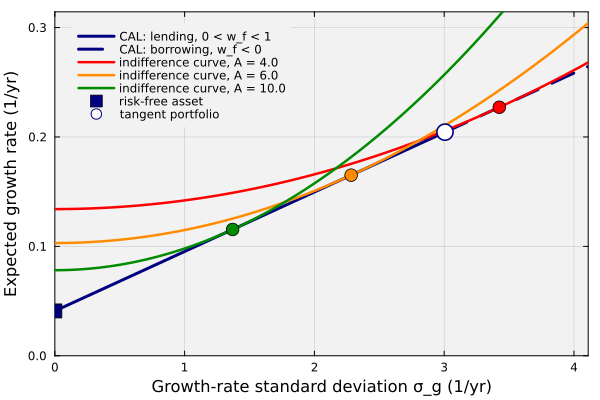

In [13]:
let
    # Find the risky fraction of each plotted investor and the right plot limit -
    x_plot = [(g_tan - g_f)/(A*Δt*σ_tan^2) for A ∈ plotted_risk_aversion]; # 1 - w_f* for each plotted A
    σ_max = 1.2*max(σ_tan, maximum(abs.(x_plot))*σ_tan); # right plot limit (1/yr)
    SR_tan = (g_tan - g_f)/σ_tan; # slope of the capital allocation line (one day)

    # Plot the capital allocation line, solid for lending and dashed for borrowing -
    plot([0.0, σ_tan], [g_f, g_tan], lw = 3, c = :navy, label = "CAL: lending, 0 < w_f < 1")
    plot!([σ_tan, σ_max], [g_tan, g_f + SR_tan*σ_max], lw = 3, ls = :dash, c = :navy, label = "CAL: borrowing, w_f < 0")

    # Draw each investor's indifference curve through the optimal portfolio -
    σ_grid = range(0.0, stop = σ_max, length = 200) |> collect; # standard deviations to evaluate (1/yr)
    colors = [:red, :darkorange, :green4]; # one color per plotted A
    for (A, x, c) ∈ zip(plotted_risk_aversion, x_plot, colors)
        E_star = g_f + x*(g_tan - g_f); # optimal expected growth rate (1/yr)
        σ_star = abs(x)*σ_tan; # optimal growth-rate standard deviation (1/yr)
        U_star = E_star - (A/2)*Δt*σ_star^2; # maximum utility (1/yr)
        plot!(σ_grid, U_star .+ (A/2)*Δt .* σ_grid.^2, lw = 2.5, c = c, label = "indifference curve, A = $(A)")
        scatter!([σ_star], [E_star], ms = 7, c = c, label = "") # the optimal complete portfolio
    end

    # Add the risk-free asset and the tangent portfolio -
    scatter!([0.0], [g_f], ms = 7, c = :navy, marker = :square, label = "risk-free asset")
    scatter!([σ_tan], [g_tan], ms = 9, c = :white, msc = :navy, msw = 2, label = "tangent portfolio")

    # Style the plot -
    plot!(xlabel = "Growth-rate standard deviation σ_g (1/yr)", ylabel = "Expected growth rate (1/yr)",
        xlim = (0.0, σ_max), ylim = (0.0, g_f + SR_tan*σ_max + 0.05),
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft)
end

__What do we see?__ Each curve touches the line at one point, that investor's optimal complete portfolio. A larger $A$ makes the curve steeper, so the touching point moves toward the risk-free asset.

___

## Task 3: What Risk Aversion Does the Client's Answer Imply?
In this task, we run the optimal-fraction formula backward to find the risk aversion behind each interview answer. Then we compare the client's choice with the one the 2025 data would have made.

### Invert the interview answers
The L6b interview asks the client for a risk-free fraction $w_{f}$. Solving the Task 2 result for $A$ gives the coefficient that makes that fraction optimal:

$$
A = \frac{\mathbb{E}[g_{\mathcal{T}}]-g_{f}}{(1-w_{f})\,\Delta t\,\sigma^{2}_{g,\mathcal{T}}}
$$

Let's compute it for each answer and mark the client's. If the income-gamble interview has run, we also add the two ends of the client's range of $A$, with the fraction each would choose:

In [14]:
let
    # Compute the risk aversion that makes each answer's w_f optimal -
    df = DataFrame(answer = String[], w_f = Float64[], risky_fraction = Float64[], A = Float64[]);
    for (answer, w_f) ∈ zip(interview_answers, interview_fractions)
        A = (g_tan - g_f)/((1 - w_f)*Δt*σ_tan^2); # implied risk aversion (dimensionless)
        label = (w_f == client_w_f) ? "$(answer) (client)" : answer; # mark the client's answer
        push!(df, (answer = label, w_f = w_f, risky_fraction = 1 - w_f, A = A));
    end

    # Add the client as a separate row if the interview file holds another fraction -
    if (client_w_f ∉ interview_fractions)
        push!(df, (answer = "client", w_f = client_w_f, risky_fraction = 1 - client_w_f,
            A = (g_tan - g_f)/((1 - client_w_f)*Δt*σ_tan^2)));
    end

    # Add the ends of the income-gamble range, running the Task 2 formula forward -
    if !isnothing(client_A_range)
        for (name, A) ∈ zip(["income gamble, low A", "income gamble, high A"], client_A_range)
            x = (g_tan - g_f)/(A*Δt*σ_tan^2); # optimal risky fraction 1 - w_f* (zero when A = Inf)
            push!(df, (answer = name, w_f = 1 - x, risky_fraction = x, A = A));
        end
    end
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false,
        formatters = [fmt__printf("%.2f", [2, 3, 4])],
        table_format = TextTableFormat(borders = text_table_borders__compact))

    # Say where the A behind the client's L6b answer falls in the income-gamble range -
    if !isnothing(client_A_range)
        A_client = (g_tan - g_f)/((1 - client_w_f)*Δt*σ_tan^2); # A that makes the client's w_f optimal
        place = (A_client < client_A_range[1]) ? "below" : ((A_client > client_A_range[2]) ? "above" : "inside");
        println("The client's w_f = $(client_w_f) implies A = $(round(A_client, digits=2)), $(place) the income-gamble range")
    end
end

 --------------------------- --------- ---------------- ---------
                     answer       w_f   risky_fraction         A 
                     String   Float64          Float64   Float64 
 --------------------------- --------- ---------------- ---------
       Keep half in T-bills      0.50             0.50      9.11
  Keep a quarter in T-bills      0.25             0.75      6.08
    Fully invested (client)      0.00             1.00      4.56
      Borrow a quarter more     -0.25             1.25      3.65
 --------------------------- --------- ---------------- ---------


__What do we see?__ The answers that lend imply an $A$ above $A_{\mathcal{T}}$, and the answer that borrows implies one below it. The implied $A$ also depends on the firms: a different ticker list changes $\mathbb{E}[g_{\mathcal{T}}]$ and $\sigma_{g,\mathcal{T}}$, so the same answer implies a different $A$. When the income-gamble rows are present, the client answered both interviews consistently if the $A$ behind the L6b answer lies between them.

### Compare the client's choice with 2025
The client's fraction rests on the 2014 to 2024 estimates of $\mathbb{E}[g_{\mathcal{T}}]$ and $\sigma_{g,\mathcal{T}}$. Let's hold $\mathcal{T}$ through 2025 and measure its realized growth rate and growth-rate standard deviation. Then we find the fraction the client's $A$ would choose with those values.

We store the client's coefficient in `client_A::Float64` and the 2025 values in `g_tan_2025::Float64` and `σ_tan_2025::Float64`:

In [15]:
client_A = (g_tan - g_f)/((1 - client_w_f)*Δt*σ_tan^2); # the client's implied risk aversion (dimensionless)

g_tan_2025, σ_tan_2025 = let
    N = nrow(dataset_2025["AAPL"]); # number of 2025 trading days (price rows)
    M = length(my_list_of_tickers); # number of selected firms

    # Fill the N × M price matrix, one firm per column in ticker order -
    S = Array{Float64,2}(undef, N, M); # undef leaves entries unset until the loop fills them
    for (i, ticker) ∈ enumerate(my_list_of_tickers)
        S[:,i] = dataset_2025[ticker][:, :volume_weighted_average_price]; # VWAP S_i(t) (USD/share)
    end

    # Hold T through 2025 and measure its growth -
    # S[1,:]' is the first-day price row (1 × M). ./ divides each column by its S_i(0).
    W = (S ./ S[1,:]')*w_tan_sim; # wealth ratio W_t/W_0 = Σᵢ w_T,i S_i(t)/S_i(0), one entry per day
    T = (N - 1)*Δt; # number of trading intervals times Δt (yr)
    g_daily = diff(log.(W)) ./ Δt; # ln(W_{t_k}/W_{t_{k-1}})/Δt for each interval (1/yr)
    (log(W[end]/W[1])/T, std(g_daily)); # realized growth rate and growth-rate standard deviation (1/yr)
end;

The table puts the model's values next to the realized 2025 values. For each row, it gives the annualized Sharpe ratio, $A_{\mathcal{T}}$, and the risky fraction $1-w_{f}^{\star}$ at the client's $A$:

In [16]:
let
    # Compare the model inputs with the 2025 values -
    df = DataFrame(inputs = String[], growth = Float64[], σ_g = Float64[], SR_annual = Float64[],
        A_T = Float64[], client_risky_fraction = Float64[]);
    for (name, g, σ) ∈ [("SIM, 2014 to 2024", g_tan, σ_tan), ("realized, 2025", g_tan_2025, σ_tan_2025)]
        push!(df, (inputs = name, growth = g, σ_g = σ,
            SR_annual = (g - g_f)/(σ*sqrt(Δt)), # annualized Sharpe ratio, as in L7a
            A_T = (g - g_f)/(Δt*σ^2), # the A that holds T alone
            client_risky_fraction = (g - g_f)/(client_A*Δt*σ^2))); # 1 - w_f* at the client's A (negative would mean shorting T)
    end
    println("client: w_f = $(client_w_f), implied A = $(round(client_A, digits=2))")
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false,
        formatters = [fmt__printf("%.3f", [2, 3, 4, 5, 6])],
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

client: w_f = 0.0, implied A = 4.56
 ------------------- --------- --------- ----------- --------- -----------------------
             inputs    growth       σ_g   SR_annual       A_T   client_risky_fraction 
             String   Float64   Float64     Float64   Float64                 Float64 
 ------------------- --------- --------- ----------- --------- -----------------------
  SIM, 2014 to 2024     0.204     3.006       0.863     4.557                   1.000
     realized, 2025     0.252     3.053       1.095     5.695                   1.250
 ------------------- --------- --------- ----------- --------- -----------------------


__What do we see?__
- __The inputs moved:__ Compare the `growth` and `σ_g` columns. The model's numbers are estimates from 2014 to 2024, while 2025 is one year of one path.
- __The fraction moved with them:__ The optimal risky fraction is proportional to the excess growth and inversely proportional to the variance. Doubling the excess growth doubles the client's risky fraction, and doubling the variance halves it.

___

## Summary
In this example, we found the tangent portfolio with SIM inputs and used mean-variance utility to choose a point on its capital allocation line. We then ran the result backward to find the risk aversion behind each interview answer and compared the client's choice with the 2025 data.

> __Key Takeaways:__
>
> * __The tangent portfolio sets the line:__ We swept the growth target with SIM inputs and rescaled the solutions to find the tangent portfolio. Its expected growth rate and risk, with the risk-free rate, are all the utility calculation needs.
> * __Risk aversion picks the point:__ We computed the optimal risk-free fraction for several risk-aversion coefficients and drew the indifference curves that touch the line. More risk-averse investors lend more, and the risky fraction falls in proportion to one over the coefficient.
> * __An interview answer implies a risk aversion:__ We inverted the optimal-fraction formula to turn each interview answer into a risk-aversion coefficient. Holding that coefficient fixed, we recomputed the fraction from the tangent portfolio's 2025 values to see how much the choice depends on the estimated inputs.

We can now change the tickers or the risk-aversion coefficients and see how the optimal complete portfolio responds. The next example writes the investor's preferences firm by firm, with Cobb–Douglas and CES utility, instead of choosing one risky fund.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___